# Optimization algorithm

前節まででは様々な事例に対して、 構造最適化を適用してみました。<br/>
本節では、構造最適化の際に適用を行った局所最適化アルゴリズムについて学んでいきます。

## アルゴリズムの種類

局所最適化アルゴリズムとして、ASEではMolecular Dynamics (MD)に似た振る舞いで最適化を行う `FIRE` や、2次関数近似をおこなって最適化を行う `BFGS`, `LBFGS`, `BFGSLineSearch`=`QuasiNewton`, `LBFGSLineSearch`法などが提供されています。

 - https://wiki.fysik.dtu.dk/ase/ase/optimize.html
 
|  アルゴリズム  | グループ | 特徴 |
| ---- | ---- | ---- |
| MDMin | MD-like  | MDを行うが、運動量とForceの内積が負になると運動量を0にリセットする |
| FIRE　 |  MD-like  | MDを行うが、様々な追加の工夫を入れて高速かつ頑健にしたもの |
| BFGS  | 準Newton法  | 最適化のトラジェクトリからヘシアンを近似し、近似ヘシアンを用いてNewton法のアルゴリズムを実行 |
| LBFGS  | 準Newton法  | BFGS法を高速・低メモリで動くようにしたもの |
| BFGSLineSearch  | 準Newton法  | BFGSで最適化のステップの方向を決定し、ステップの大きさはLineSearchで決定 |
| LBFGSLineSearch  | 準Newton法  | LBFGSで最適化のステップの方向を決定し、ステップの大きさはLineSearchで決定 |


MDMinはハイパーパラメーター依存性が大きく、構造最適化に失敗することも多いためベンチマークから除外し、他のOptimizerを見ていきます。

### FIRE

FIREでは基本的にMDを行いますが、高速に収束するように様々な工夫が加えられています。

### ニュートン法

ニュートン法ではヘシアンと勾配を用いて次のステップを決定します。ニュートン法は二次収束する手法であり、ポテンシャルが二次関数に近い時（極小点に近い時）真の解に二乗の速度で近づいていき非常に高速です。
ヘシアンを $H$、勾配を $\vec{g}$ として、次の最適化ステップ $\vec{p}$ を以下の式で表現します。

$\vec{p} = - H^{-1} \vec{g}$

仮にポテンシャルが厳密に二次関数であれば1ステップで極小値に収束します。

### 準ニュートン法

ヘシアンの評価は非常に重い（例えば数値計算なら6N回Forceを計算して求めることが出来る）ため、ヘシアンを計算している時間を使って構造最適化を進める方が有意義であることが良くあります。  
そこで、最適化のトラジェクトリを使って短時間でヘシアンを近似するのが準ニュートン法です。  
ヘシアンが厳密でないためNewton法ほど少ないステップ数で収束するというわけにはいきませんが、それでもかなり高速に収束します。

### BFGS

BFGS法は準ニュートン法の中でも最も標準的に使われているヘシアン近似方法です。  
他にも SR1法やDFP法等様々な方法が知られていますが、ASEではBFGS法が実装されています。

### LBFGS

BFGS法の欠点として、最適化した変数の次元の大きさの行列を格納し行列ベクトル積を計算しないといけないというものがあります。  
これは空間計算量が次元 $N$ に対して $O(N^2)$ 、時間計算量も $O(N^2)$ となり、多次元の関数を最適化するのに不向きです。  
そこで直近のいくつかのトラジェクトリの情報だけを用いてBFGS法とほとんど同じ結果になるように変形し、$O(N)$ の計算量でBFGSをほとんど再現できるようにしたのがLBFGS法です。    
PFPの計算量は $O(N)$ なので、BFGSのような $O(N^2)$ の手法を用いると原子数300程度からOptimizerでの計算時間が目立ってきますが、LBFGSだと原子数が増えてもOptimizerの計算時間は目立ってきません。  

### LineSearch

ポテンシャルが二次関数でない場合、ニュートン法は振動してしまうことがあります。また、準ニュートン法ではヘシアンが正確でないこともあり、適切なステップサイズを提示できないことがあります。  
このような場合でも最適化を収束させるため、LineSearchを行うと最適化が安定します。  
準ニュートン法で最適化の方向を決めた後、最適化のステップサイズに関してはその方向にエネルギーが十分小さくなるようなステップサイズをとることが望ましいです。このようなステップサイズを実際に何点か計算してみて決定するのがLineSearchです。  
BFGS等だとニュートン法の方法に従って計算した結果エネルギーが上がってしまったというようなケースがありえますが、BFGSLineSearchだとそのようなケースでも良いステップサイズを探索します。

## ベンチマーク

In [1]:
from orb_compat import ASECalculator, Estimator, EstimatorCalcMode, pfp_api_client
import os
from time import perf_counter
from typing import Optional, Type

import matplotlib.pyplot as plt
import pandas as pd
from ase import Atoms
from ase.build import bulk, molecule
from ase.calculators.calculator import Calculator
from ase.io import Trajectory
from ase.optimize import BFGS, FIRE, LBFGS, BFGSLineSearch, LBFGSLineSearch, MDMin
from ase.optimize.optimize import Optimizer
from tqdm.auto import tqdm

from pfcc_extras.structure.ase_rdkit_converter import atoms_to_smiles, smiles_to_atoms
from pfcc_extras.visualize.view import view_ngl


In [2]:
calc = ASECalculator(Estimator(calc_mode=EstimatorCalcMode.PBE, model_version="v8.0.0"))
calc_mol = ASECalculator(Estimator(calc_mode=EstimatorCalcMode.WB97XD, model_version="v8.0.0"))
print(f"pfp_api_client: {pfp_api_client.__version__}")
print(calc.estimator.model_version)

pfp_api_client: 1.23.1
v8.0.0


### Force計算回数の比較

以下はCH3CHO分子の構造最適化を行う簡単な例です。<br/>
`molecule("CH3CHO")` で得られる構造は厳密な安定構造ではありませんが、かなり良い構造をしています。  
このような構造から開始した時には準ニュートン法を用いるとかなり少ない回数のPFP呼び出しで構造最適化を完了することが出来ます。  

まずは構造最適化が完了するまでにForceを何回計算するかベンチマークをとってみましょう。  
ここではPtのバルクを乱数で動かした構造を初期値として、最適構造になるまでのForce計算回数を測定します。  

In [3]:
def get_force_calls(opt: Optimizer) -> int:
    """Obtrain number of force calculations"""
    if isinstance(opt, (BFGSLineSearch, LBFGSLineSearch)):
        return opt.force_calls
    else:
        return opt.nsteps

In [4]:
os.makedirs("output", exist_ok=True)

In [5]:
atoms_0 = bulk("Pt") * (4, 4, 4)
atoms_0.rattle(stdev=0.1)

In [6]:
view_ngl(atoms_0)

In [7]:
force_calls = {}
for opt_class in tqdm([FIRE, BFGS, LBFGS, BFGSLineSearch, LBFGSLineSearch]):
    atoms = atoms_0.copy()
    atoms.calc = calc
    name = opt_class.__name__
    with opt_class(atoms, trajectory=f"output/{name}_ch3cho.traj", logfile=None) as opt:
        opt.run(fmax=0.05)
        force_calls[name] = [get_force_calls(opt)]

  0%|          | 0/5 [00:00<?, ?it/s]

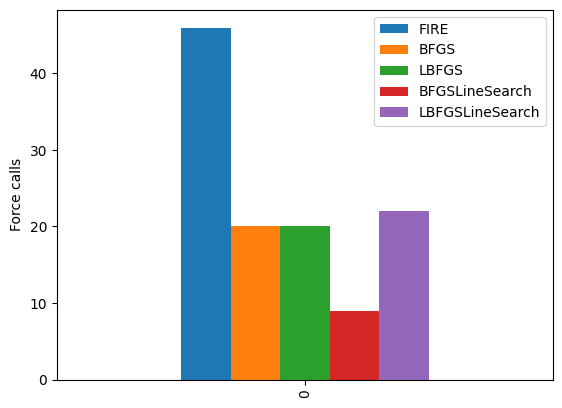

In [8]:
df = pd.DataFrame.from_dict(force_calls)
df.plot.bar()
plt.ylabel("Force calls")
plt.show()

FIREが抜きんでてForce評価回数が多く、BFGSとLBFGSは同じくらいとなりました。  
また、LineSearchのある手法もBFGSやLBFGSと同じくらいのForce評価回数となりました。

### 1ステップあたりの速度比較

次に同じそれぞれの最適化手法の1stepあたりの速度を比較してみます。

In [9]:
from ase.build import bulk

atoms = bulk("Fe") * (10, 5, 3)
atoms.rattle(stdev=0.2)
atoms.calc = calc

view_ngl(atoms)

In [10]:
def opt_benchmark(atoms: Atoms, calculator: Calculator, opt_class, logfile: Optional[str] = "-", steps: int = 10) -> float:
    _atoms = atoms.copy()
    _atoms.calc = calculator
    with opt_class(_atoms, logfile=logfile) as opt:
        start_time = perf_counter()
        opt.run(steps=steps)
        end_time = perf_counter()
        duration = end_time - start_time
        duration_per_force_calls = duration / get_force_calls(opt)
    return duration_per_force_calls

In [11]:
result_dict = {
    "n_atoms": [],
    "FIRE": [],
    "BFGS": [],
    "LBFGS": [],
    "BFGSLineSearch": [],
    "LBFGSLineSearch": [],
}


for i in range(1, 10):
    atoms = bulk("Fe") * (10, 10, i)
    atoms.rattle(stdev=0.2)
    n_atoms = atoms.get_global_number_of_atoms()
    result_dict["n_atoms"].append(n_atoms)
    print(f"----- n_atoms {n_atoms} -----")
    for opt_class in [FIRE, BFGS, LBFGS, BFGSLineSearch, LBFGSLineSearch]:
        name = opt_class.__name__
        print(f"Running {name}...")
        duration = opt_benchmark(atoms, calc, opt_class=opt_class, logfile=None, steps=10)
        print(f"Done in {duration:.2f} sec.")
        result_dict[name].append(duration)

----- n_atoms 100 -----
Running FIRE...
Done in 0.10 sec.
Running BFGS...
Done in 0.10 sec.
Running LBFGS...
Done in 0.09 sec.
Running BFGSLineSearch...
Done in 0.08 sec.
Running LBFGSLineSearch...
Done in 0.08 sec.
----- n_atoms 200 -----
Running FIRE...
Done in 0.09 sec.
Running BFGS...
Done in 0.15 sec.
Running LBFGS...
Done in 0.09 sec.
Running BFGSLineSearch...
Done in 0.11 sec.
Running LBFGSLineSearch...
Done in 0.09 sec.
----- n_atoms 300 -----
Running FIRE...
Done in 0.13 sec.
Running BFGS...
Done in 0.29 sec.
Running LBFGS...
Done in 0.15 sec.
Running BFGSLineSearch...
Done in 0.18 sec.
Running LBFGSLineSearch...
Done in 0.10 sec.
----- n_atoms 400 -----
Running FIRE...
Done in 0.08 sec.
Running BFGS...
Done in 0.42 sec.
Running LBFGS...
Done in 0.10 sec.
Running BFGSLineSearch...
Done in 0.19 sec.
Running LBFGSLineSearch...
Done in 0.08 sec.
----- n_atoms 500 -----
Running FIRE...
Done in 0.10 sec.
Running BFGS...
Done in 0.73 sec.
Running LBFGS...
Done in 0.09 sec.
Running B

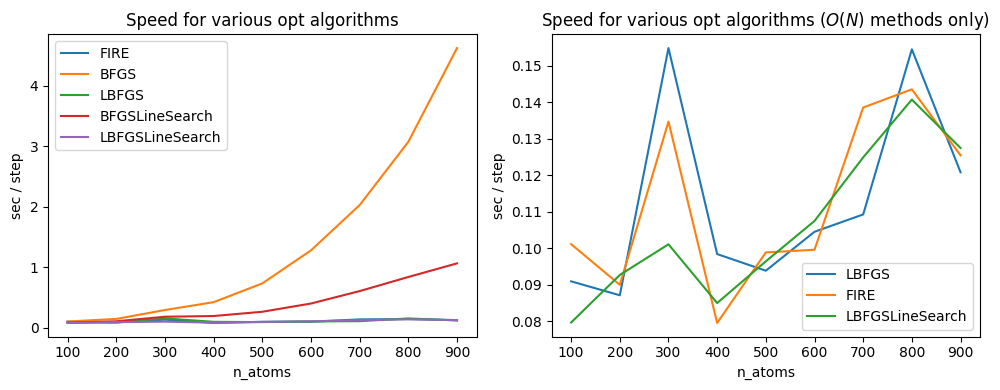

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
df = pd.DataFrame(result_dict)
df = df.set_index("n_atoms")
df.plot(ax=axes[0])
axes[0].set_title("Speed for various opt algorithms")
df[["LBFGS", "FIRE", "LBFGSLineSearch"]].plot(ax=axes[1])
axes[1].set_title("Speed for various opt algorithms ($O(N)$ methods only)")
for ax in axes:
    ax.set_ylabel("sec / step")
fig.savefig("output/opt_benchmark.png")
plt.show(fig)

BFGSやBFGSLineSearchでは原子数が多くなるにつれて1ステップあたりの計算時間が長くなってしまっています。  

ASEに実装されているBFGS法ではHessianの逆行列を求める際に固有値分解を毎ステップごとに行います。  
Hessianは縦横それぞれ原子数をNとして3Nの大きさをもっており、固有値分解の計算量は $O(N^3)$ であるため、ASEのBFGS法は原子数の3乗のオーダーで急速に遅くなっていきます。 

また、BFGSLineSearchではHessianの固有値分解を行うことなく、Hessianの逆行列を直接近似します。このため、行列ベクトル積が律速になり $O(N^2)$ とBFGSよりは速くなります。  
しかし、原子数が多い時には $O(N)$ で動作するLBFGSやFIREよりはずっと遅くなります。 

## 最適化アルゴリズムの使い分け

これまでに、FIREは他の手法よりもForce呼び出し回数が多く、BFGSやBFGSLineSearchは原子数が多くなるとForceの評価よりもOptimizerの内部ルーチンの方が律速になることを見てきました。  
ではどういった場合でもLBFGSとLBFGSLineSearchを用いると良いのでしょうか？  
これからそれらのアルゴリズムでもうまくいかない例もあることを見ていきましょう。  

### LBFGSやBFGSがうまくいかない例


次の例を見てみましょう。
この例ではとても単純なポテンシャルである Lennard-Jones (LJ) potentialを用いて、その安定点から離れたところを初期値として構造最適化を行っています。

 - https://wiki.fysik.dtu.dk/ase/ase/calculators/others.html#lennard-jones

LJ potential は次式で表される形をしており、以下のような形をしています。

$$ \phi (r) = 4 \epsilon \bigg\{ \left( \frac{\sigma}{r} \right) ^{12} -  \left( \frac{\sigma}{r} \right) ^{6} \bigg\} $$

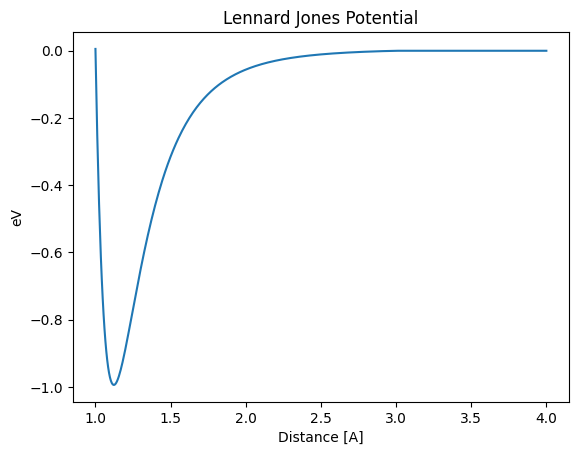

In [13]:
from ase.calculators.lj import LennardJones
import numpy as np


calc_lj = LennardJones()

dists = np.linspace(1.0, 4.0, 500)


E_pot_list = []
for d in dists:
    atoms = Atoms("Ar2", [[0, 0, 0], [d, 0, 0]])
    atoms.calc = calc_lj
    E_pot = atoms.get_potential_energy()
    E_pot_list.append(E_pot)

plt.plot(dists, E_pot_list)
plt.title("Lennard Jones Potential")
plt.ylabel("eV")
plt.xlabel("Distance [A]")
plt.show()

この単純なPotential の形でDistanceを安定点である1.12A から離れたところからスタートし構造最適化をしてみましょう。

In [14]:
def lennard_jones_trajectory(opt_class: Type[Optimizer], d0: float):
    name = opt_class.__name__
    trajectory_path = f"output/Ar_{name}.traj"

    atoms = Atoms("Ar2", [[0, 0, 0], [d0, 0, 0]])
    atoms.calc = calc_lj

    opt = opt_class(atoms, trajectory=trajectory_path)
    opt.run()

    distance_list = []
    energy_list = []
    for atoms in Trajectory(trajectory_path):
        energy_list.append(atoms.get_potential_energy())
        distance_list.append(atoms.get_distance(0, 1))

    print("Distance in opt trajectory: ", distance_list)

    plt.plot(dists, E_pot_list)
    plt.plot(distance_list, energy_list, marker="x")
    plt.title(f"Lennard Jones Potential: {name} opt")
    plt.ylim(-1.0, 0)
    plt.ylabel("eV")
    plt.xlabel("Distance [A]")
    plt.show()

まずはFIREを行った場合です。安定して最適値1.12A にたどり着くことが出来ています。

      Step     Time          Energy          fmax
FIRE:    0 04:30:07       -0.314857        1.158029
FIRE:    1 04:30:07       -0.342894        1.264380
FIRE:    2 04:30:07       -0.410024        1.512419
FIRE:    3 04:30:07       -0.546744        1.968308
FIRE:    4 04:30:07       -0.812180        2.383891
FIRE:    5 04:30:07       -0.862167        5.585844
FIRE:    6 04:30:07       -0.966377        2.149190
FIRE:    7 04:30:07       -0.991817        0.522302
FIRE:    8 04:30:07       -0.992148        0.491275
FIRE:    9 04:30:07       -0.992732        0.429940
FIRE:   10 04:30:07       -0.993427        0.339973
FIRE:   11 04:30:07       -0.994057        0.224455
FIRE:   12 04:30:07       -0.994451        0.088426
FIRE:   13 04:30:07       -0.994489        0.060610
FIRE:   14 04:30:07       -0.994490        0.059506
FIRE:   15 04:30:07       -0.994492        0.057320
FIRE:   16 04:30:07       -0.994495        0.054094
FIRE:   17 04:30:07       -0.994499        0.049889
Distance in op

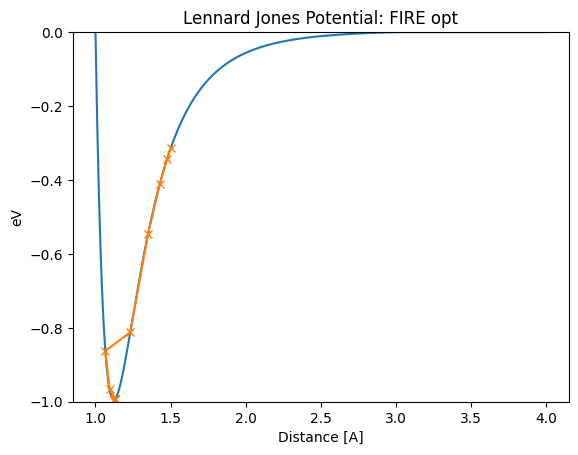

In [15]:
lennard_jones_trajectory(FIRE, 1.5)

      Step     Time          Energy          fmax
FIRE:    0 04:30:08       -0.697220        2.324552
FIRE:    1 04:30:08       -0.807702        2.387400
FIRE:    2 04:30:08       -0.987241        0.821987
FIRE:    3 04:30:08       -0.520102       13.570402
FIRE:    4 04:30:08       -0.971689        1.903593
FIRE:    5 04:30:08       -0.939109        1.840004
FIRE:    6 04:30:08       -0.943288        1.793714
FIRE:    7 04:30:08       -0.951214        1.694594
FIRE:    8 04:30:08       -0.961964        1.529352
FIRE:    9 04:30:08       -0.974030        1.277952
FIRE:   10 04:30:08       -0.985244        0.914936
FIRE:   11 04:30:08       -0.992867        0.414203
FIRE:   12 04:30:08       -0.994043        0.239611
FIRE:   13 04:30:08       -0.994061        0.235001
FIRE:   14 04:30:08       -0.994095        0.225890
FIRE:   15 04:30:08       -0.994143        0.212487
FIRE:   16 04:30:08       -0.994201        0.195100
FIRE:   17 04:30:08       -0.994265        0.174121
FIRE:   18 04:

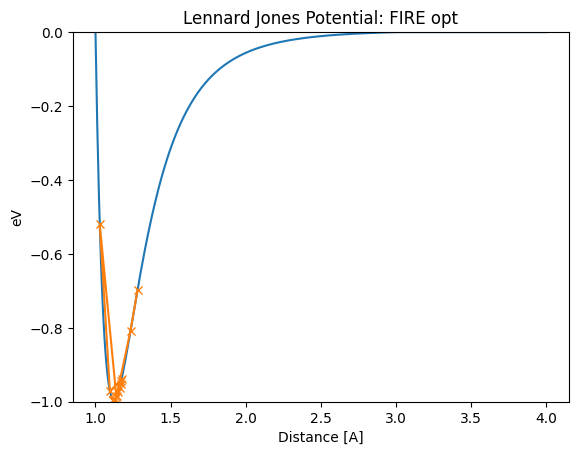

In [16]:
lennard_jones_trajectory(FIRE, 1.28)

BFGS法を1.5Aから開始した場合、特定のstepではあまりにも大きくジャンプしてしまい、安定点を大きく飛び越えるような不安定な挙動になっていることがわかります。<br/>
(1.18A --> 0.78Aにジャンプしているようなところです。)<br/>
このように、最適値1.12A にたどり着くまでに、この単純な例でも大きく振動しまいます。<br/>
これは2次の近似を行う手法では、関数曲面が2次関数と異なる場合に、その極小値の見積もりが大きくはずれてしまうために起こります。

      Step     Time          Energy          fmax
BFGS:    0 04:30:08       -0.314857        1.158029
BFGS:    1 04:30:08       -0.355681        1.312428
BFGS:    2 04:30:08       -0.916039        2.041011
BFGS:    3 04:30:08       55.304434      974.487533
BFGS:    4 04:30:08       -0.917740        2.028761
BFGS:    5 04:30:08       -0.919418        2.016337
BFGS:    6 04:30:08       -0.747080        8.517609
BFGS:    7 04:30:08       -0.965068        1.472894
BFGS:    8 04:30:08       -0.984660        0.939655
BFGS:    9 04:30:08       -0.992324        0.528593
BFGS:   10 04:30:08       -0.994444        0.092418
BFGS:   11 04:30:08       -0.994520        0.007274
Distance in opt trajectory:  [1.5, 1.4669134619701096, 1.1856710148074785, 0.7856710148074794, 1.1848349876531552, 1.1840057048694352, 1.0494144415981015, 1.1582431525834522, 1.1421985974452062, 1.1139254943723917, 1.1241042745909042, 1.1225894828343739]


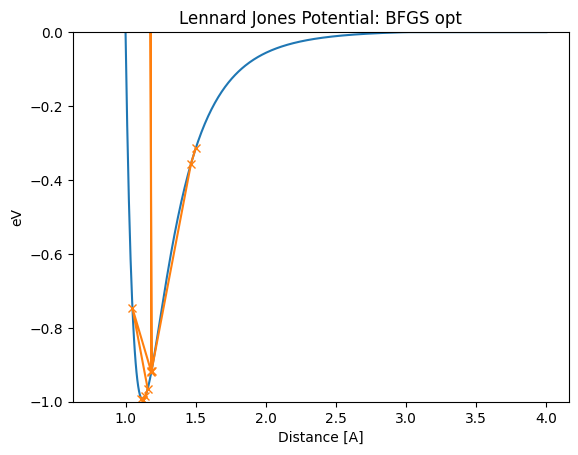

In [17]:
lennard_jones_trajectory(BFGS, 1.5)

同じことがLBFGS法でも起こります。  
このような振動が多原子系で起こった場合、本当にいつまでたっても最適化が終了しないような場合もあります。

       Step     Time          Energy          fmax
LBFGS:    0 04:30:08       -0.697220        2.324552
LBFGS:    1 04:30:08       -0.854683        2.314904
LBFGS:    2 04:30:08       33.771592      599.751912
LBFGS:    3 04:30:08       -0.858237        2.305680
LBFGS:    4 04:30:08       -0.861748        2.295944
LBFGS:    5 04:30:08       17.305333      318.491824
LBFGS:    6 04:30:08       -0.867638        2.278148
LBFGS:    7 04:30:08       -0.873395        2.258876
LBFGS:    8 04:30:08        5.604073      121.154807
LBFGS:    9 04:30:08       -0.885566        2.211348
LBFGS:   10 04:30:08       -0.897001        2.157091
LBFGS:   11 04:30:08        0.369118       30.787165
LBFGS:   12 04:30:08       -0.925197        1.970726
LBFGS:   13 04:30:08       -0.947015        1.749104
LBFGS:   14 04:30:08       -0.915603        4.009032
LBFGS:   15 04:30:08       -0.985429        0.906882
LBFGS:   16 04:30:08       -0.993163        0.377052
LBFGS:   17 04:30:08       -0.994465        0.08

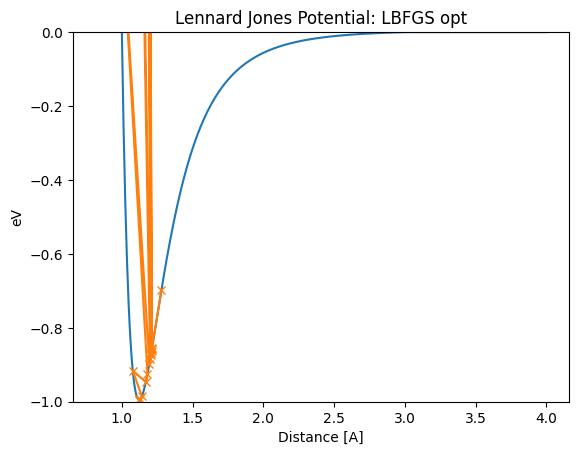

In [18]:
lennard_jones_trajectory(LBFGS, 1.28)

また、他にも初期値が安定点から離れたところからスタートした場合に正しく安定点にたどり着けていないケースも有ります。<br/>
これは、Hessianの初期化がうまく行かないなどの理由で起きていると考えられます。

       Step     Time          Energy          fmax
LBFGS:    0 04:30:09       -0.314857        1.158029
LBFGS:    1 04:30:09       -0.355681        1.312428
LBFGS:    2 04:30:09       -0.129756        0.447300
LBFGS:    3 04:30:09       -0.079409        0.263016
LBFGS:    4 04:30:09       -0.040472        0.129677
LBFGS:    5 04:30:09       -0.021155        0.068924
LBFGS:    6 04:30:09       -0.009646        0.035707
Distance in opt trajectory:  [1.5, 1.4669134619701096, 1.748155909132741, 1.8935676545167726, 2.101103976550205, 2.302941039822042, 2.531922335240822]


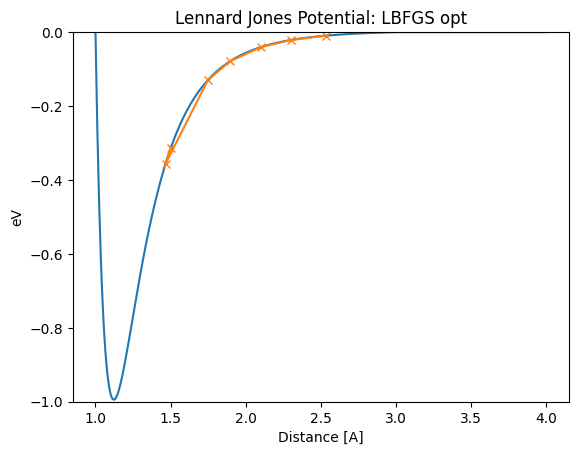

In [19]:
lennard_jones_trajectory(LBFGS, 1.50)

このようにBFGSやLBFGSがうまくいかない例であっても、LineSearchを行うことで正しく収束させることが出来ます。  
LBFGSLineSearchはほとんどの場合において最良のOptimizerです。

                 Step     Time          Energy          fmax
LBFGSLineSearch:    0 04:30:09       -0.314857        1.158029
LBFGSLineSearch:    1 04:30:09       -0.994517        0.021446
Distance in opt trajectory:  [1.5, 1.1220880716401869]


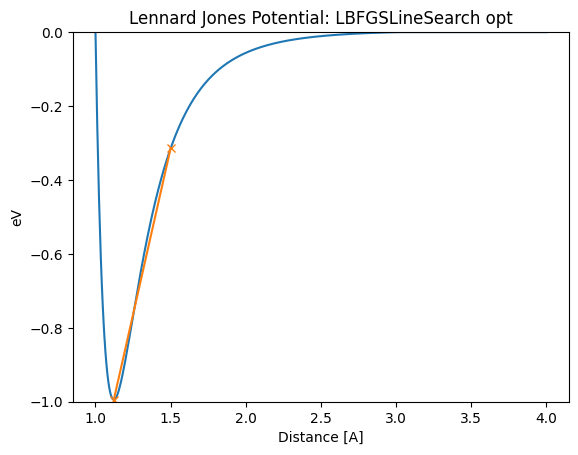

In [20]:
lennard_jones_trajectory(LBFGSLineSearch, 1.5)

LBFGSLineSearchでは1ステップで終了しているように見えますが、内部でLineSearchを行っている部分がステップにカウントされていないため、実際の計算数はもう少し多いです。</br>
BFGSLineSearchでは Step[FC]という表示がありますが、このFCが実際のフォース評価回数です。

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 04:30:09       -0.314857       1.1580
BFGSLineSearch:    1[  5] 04:30:09       -0.994057       0.2244
BFGSLineSearch:    2[  7] 04:30:09       -0.994520       0.0054
Distance in opt trajectory:  [1.5, 1.1265420003736115, 1.1225561293552997]


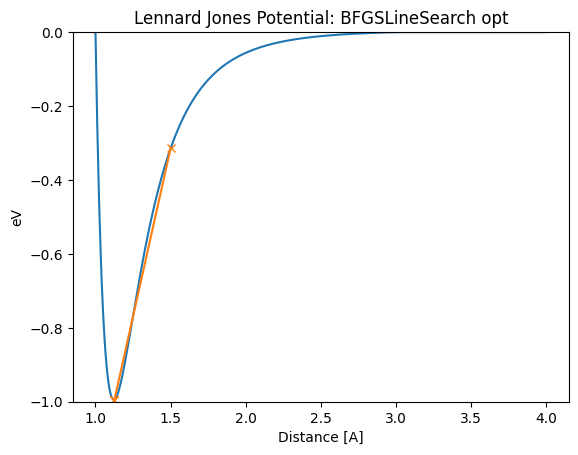

In [21]:
lennard_jones_trajectory(BFGSLineSearch, 1.5)

ここではBFGSやLBFGSがうまくいかない例があることを見てきました。
しかし、このような例であってもLBFGSLineSearchはうまくいっています。

ここまでの結論としては多くの場合においてLBFGSLineSearchが最良のOptimizerとなります。  
以下にLBFGSLineSearch以外のOptimizerの欠点を述べます。

- FIRE: 収束までのステップ数が長い
- BFGS: 原子数が多い時に計算時間がかかる。
- BFGSLineSearch: 原子数が多い時に計算時間がかかる。
- LBFGS: 振動したり、エネルギーが上がってしまう場合がある。

しかし、常にLBFGSLineSearchを使うとうまくいくかというと、現状残念ながら必ずしもそうではありません。

### LBFGSLineSearchが良くない例

LBFGSLineSearchは非常に完成度の高い手法であり、多くの場合はLBFGSLineSearchを使えばうまくいきます。  
しかし、稀にLBFGSLineSearchがうまくいかなくなってしまう例も存在します。  
例えば、fmaxを小さくして精密に構造最適化したい時に良くこのような例にあたります。  
例えばトルエンのメチル基の回転を最適化したい場合、fmax=0.001eV/A程度にしないと回転に関して極小値に到達しません。   
この例ではLineSearchがなかなか収束しなくなり1ステップに長い時間がかかるようになったり、エネルギーが下がらなくなったり、場合によってはLineSearchが破綻して `RuntimeError: LineSearch failed!` となってエラーになってしまう場合もあります。

In [22]:
atoms_0 = smiles_to_atoms("Cc1ccccc1")
tmp = atoms_0[7:10]
tmp.rotate([1.0, 0.0, 0.0], 15.0)
atoms_0.positions[7:10] = tmp.positions
atoms_0.calc = calc_mol

In [23]:
view_ngl(atoms_0, representations=["ball+stick"], h=600, w=600)

In [24]:
# Please set '-', if you want to see detailed logs.
logfile = None

steps = {}
images = []
for optimizer_class in (FIRE, LBFGS, LBFGSLineSearch):
    name = optimizer_class.__name__
    atoms = atoms_0.copy()
    atoms.calc = calc_mol
    with optimizer_class(atoms, logfile=logfile) as opt:
        try:
            print(f"{name} optimization starts.")
            opt.run(fmax=0.001, steps=200)
            print(f"Optimization finished without error. steps = {opt.nsteps}")
        finally:
            steps[name] = [get_force_calls(opt)]
            images.append(atoms.copy())

FIRE optimization starts.
Optimization finished without error. steps = 134
LBFGS optimization starts.
Optimization finished without error. steps = 47
LBFGSLineSearch optimization starts.


RuntimeError: LineSearch failed!

In [25]:
steps["index"] = "nsteps"
df = pd.DataFrame(steps)
df = df.set_index("index")
df

,FIRE,LBFGS,LBFGSLineSearch
index,,,
nsteps,134,47,325


この例ではLBFGSは収束しますが、FIREは収束しませんでした。

また、LBFGSLineSearchは後半に1ステップあたりにすごく長い時間がかかった上に収束せず、場合によっては  `RuntimeError: LineSearch failed!` というエラーが出ます。  
経験的に多くの場合はfmax=0.002eV/A 付近からLBFGSLineSearchが収束しにくくなりますが、  
もっとポテンシャルの形状が悪い場合はfmax=0.05に到達しないケースもあります。

ちなみに、このようにLBFGSLineSearchが進まなくなってしまった場合はLBFGSLineSearchを実行しなおすことで、うまくいくようになることがあります。（うまくいかない時もあります）  

In [26]:
with LBFGSLineSearch(atoms) as opt:
    opt.run(0.001)

                 Step     Time          Energy          fmax
LBFGSLineSearch:    0 04:31:43      -72.229813        0.002213
LBFGSLineSearch:    1 04:31:44      -72.229811        0.002213
LBFGSLineSearch:    2 04:31:44      -72.229812        0.000925


In [27]:
view_ngl(images, representations=["ball+stick"])

### 上記知見を踏まえた、最適化アルゴリズムの実装

LBFGSLineSearchは多くの場合最良のOptimizerですが、fmaxが小さいと非常に遅くなってしまうだけでなく、場合によってはエラーが出てしまうことがあります。  
FIREはLBFGSLineSearchと比べて遅いことが多いですが、多くの場合頑健に動作します。ただし、fmaxが小さいとなかなか収束しないことがあります。  
LBFGSはfmaxが小さくても収束しますが、Lennard-Jonesの例で見たように振動したりエネルギーが上がってしまうケースがあります。

ヒューリスティックな表現をすると、2次関数近似が良い近似となる安定点に近いところでは、収束性の良い2次のニュートン法を用いたいです。
ただし、LBFGSLineSearchが数値的に安定しないケースがあるためLBFGSを使いたいです。  
２次関数近似がよい近似とならない不安定な構造では、FIREやLBFGSLineSearchを使って頑健にエネルギーを落としたいです。  
しかし、LBFGSLineSearchが数値的に安定しないケースがどれくらのfmaxで起こるか予想しきれないため、
ハイスループット計算など、未知の物質に対して統一的に手法を適用する場合ではFIREのほうが安定に動作します。

ここまでの知見をまとめると、ヒューリスティックにうまくいきそうな最適化アルゴリズムとして、

 - 構造最適化の初期など、不安定な場所では、FIREを用いて勾配を下っていく。
 - ある程度安定点に達したら(Forceなどが小さな値になったら)LBFGS法を用いて高速に収束を試みる。

という方法がうまくいきそうです。

matlantis-features では、このようなアルゴリズムを `FIRELBFGS` Optimizer として実装をしています。

In [28]:
from ase.optimize import FIRE as FIRELBFGS

まずはLBFGSLineSearchが破綻した例であるトルエンのメチル基の回転を見てみましょう。  
このような例でも破綻することなく、LBFGSよりは遅いがFIREよりはずっと速く、頑健に収束しています。

In [29]:
atoms_0 = smiles_to_atoms("Cc1ccccc1")
tmp = atoms_0[7:10]
tmp.rotate([1.0, 0.0, 0.0], 15.0)
atoms_0.positions[7:10] = tmp.positions
atoms_0.calc = calc_mol

In [30]:
view_ngl(atoms_0, representations=["ball+stick"], h=600, w=600)

In [31]:
steps = {}
images = []
atoms = atoms_0.copy()
atoms.calc = calc_mol
with FIRELBFGS(atoms, logfile="-") as opt:
    try:
        opt.run(fmax=0.001, steps=200)
    finally:
        steps[name] = [get_force_calls(opt)]
        images.append(atoms.copy())

           Step     Time          Energy          fmax
FIRELBFGS:    0 04:31:58      -72.073380        1.815006
FIRELBFGS:    1 04:31:58      -72.146437        0.786663
FIRELBFGS:    2 04:31:58      -72.152324        1.287662
FIRELBFGS:    3 04:31:58      -72.164941        1.010978
FIRELBFGS:    4 04:31:58      -72.179629        0.534161
FIRELBFGS:    5 04:31:58      -72.186041        0.417720
FIRELBFGS:    6 04:31:59      -72.185550        0.641442
FIRELBFGS:    7 04:31:59      -72.186688        0.596239
FIRELBFGS:    8 04:31:59      -72.188711        0.510811
FIRELBFGS:    9 04:31:59      -72.191216        0.396012
FIRELBFGS:   10 04:31:59      -72.193697        0.310661
FIRELBFGS:   11 04:31:59      -72.195816        0.273045
FIRELBFGS:   12 04:31:59      -72.197418        0.261057
FIRELBFGS:   13 04:31:59      -72.198668        0.275473
FIRELBFGS:   14 04:31:59      -72.199987        0.332302
FIRELBFGS:   15 04:31:59      -72.201756        0.344170
FIRELBFGS:   16 04:31:59      -72

次に、LBFGSで大きく振動したり、ポテンシャルを登ってしまったAr二原子の例を見てみましょう。  
このような例でも破綻することなく、頑健に収束しています。

           Step     Time          Energy          fmax
FIRELBFGS:    0 04:32:07       -0.314857        1.158029
FIRELBFGS:    1 04:32:07       -0.342894        1.264380
FIRELBFGS:    2 04:32:07       -0.410024        1.512419
FIRELBFGS:    3 04:32:07       -0.546744        1.968308
FIRELBFGS:    4 04:32:07       -0.812180        2.383891
FIRELBFGS:    5 04:32:07       -0.862167        5.585844
FIRELBFGS:    6 04:32:07       -0.966377        2.149190
FIRELBFGS:    7 04:32:07       -0.991817        0.522302
FIRELBFGS:    8 04:32:07       -0.992148        0.491275
FIRELBFGS:    9 04:32:07       -0.992732        0.429940
FIRELBFGS:   10 04:32:07       -0.993427        0.339973
FIRELBFGS:   11 04:32:07       -0.994057        0.224455
FIRELBFGS:   12 04:32:07       -0.994451        0.088426
FIRELBFGS:   13 04:32:07       -0.994489        0.060610
FIRELBFGS:   14 04:32:07       -0.994490        0.059506
FIRELBFGS:   15 04:32:07       -0.994492        0.057320
FIRELBFGS:   16 04:32:07       -0

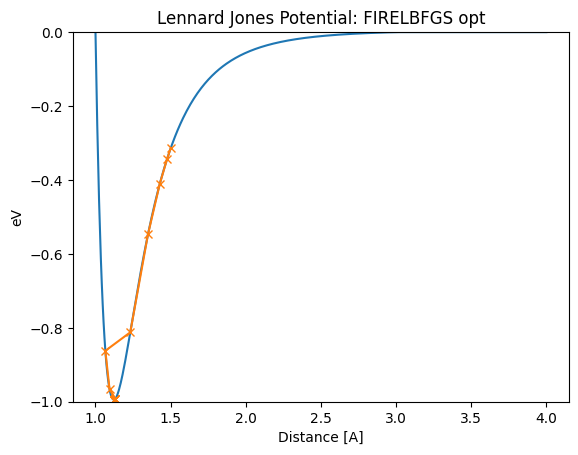

In [32]:
lennard_jones_trajectory(FIRELBFGS, 1.5)

           Step     Time          Energy          fmax
FIRELBFGS:    0 04:32:08       -0.697220        2.324552
FIRELBFGS:    1 04:32:08       -0.807702        2.387400
FIRELBFGS:    2 04:32:08       -0.987241        0.821987
FIRELBFGS:    3 04:32:08       -0.520102       13.570402
FIRELBFGS:    4 04:32:08       -0.971689        1.903593
FIRELBFGS:    5 04:32:08       -0.939109        1.840004
FIRELBFGS:    6 04:32:08       -0.943288        1.793714
FIRELBFGS:    7 04:32:08       -0.951214        1.694594
FIRELBFGS:    8 04:32:08       -0.961964        1.529352
FIRELBFGS:    9 04:32:08       -0.974030        1.277952
FIRELBFGS:   10 04:32:08       -0.985244        0.914936
FIRELBFGS:   11 04:32:08       -0.992867        0.414203
FIRELBFGS:   12 04:32:08       -0.994043        0.239611
FIRELBFGS:   13 04:32:08       -0.994061        0.235001
FIRELBFGS:   14 04:32:08       -0.994095        0.225890
FIRELBFGS:   15 04:32:08       -0.994143        0.212487
FIRELBFGS:   16 04:32:08       -0

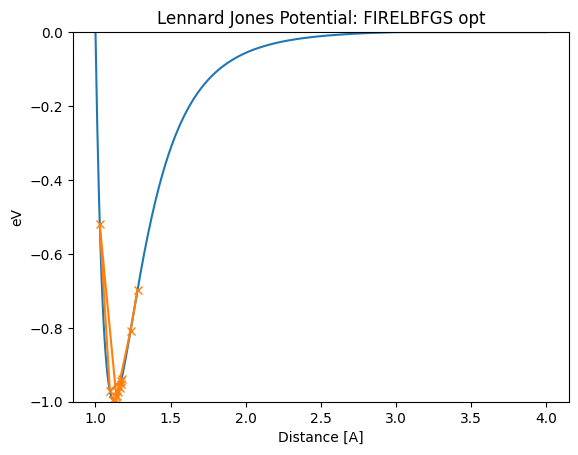

In [33]:
lennard_jones_trajectory(FIRELBFGS, 1.28)

## 更にきちんと学びたい方のために

以下書籍にニュートン法ファミリーや準ニュートン法、LineSearchなどの手法に関する詳細な解説があります。  

 - "Numerical Optimization" Jorge Nocedal, Stephan Wright https://doi.org/10.1007/978-0-387-40065-5

FIREは元論文を読むと理解しやすいでしょう。  

 - [Structural Relaxation Made Simple](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.97.170201)


また、どの手法もASEの実装を読むことで勉強することもできます。

In [34]:
from ase.optimize import FIRE
??FIRE

Init signature:
FIRE(
    atoms: ase.atoms.Atoms,
    restart: Optional[str] = None,
    logfile: Union[IO, str] = '-',
    trajectory: Optional[str] = None,
    dt: float = 0.1,
    maxstep: Optional[float] = None,
    maxmove: Optional[float] = None,
    dtmax: float = 1.0,
    Nmin: int = 5,
    finc: float = 1.1,
    fdec: float = 0.5,
    astart: float = 0.1,
    fa: float = 0.99,
    a: float = 0.1,
    downhill_check: bool = False,
    position_reset_callback: Optional[Callable] = None,
    **kwargs,
)
Docstring:      Base-class for all structure optimization classes.
Source:        
class FIRE(Optimizer):
    @deprecated(
        "Use of `maxmove` is deprecated. Use `maxstep` instead.",
        category=FutureWarning,
        callback=_forbid_maxmove,
    )
    def __init__(
        self,
        atoms: Atoms,
        restart: Optional[str] = None,
        logfile: Union[IO, str] = '-',
        trajectory: Optional[str] = None,
        dt: float = 0.1,
        maxstep: Optional